In [22]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("data/heart.csv")
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


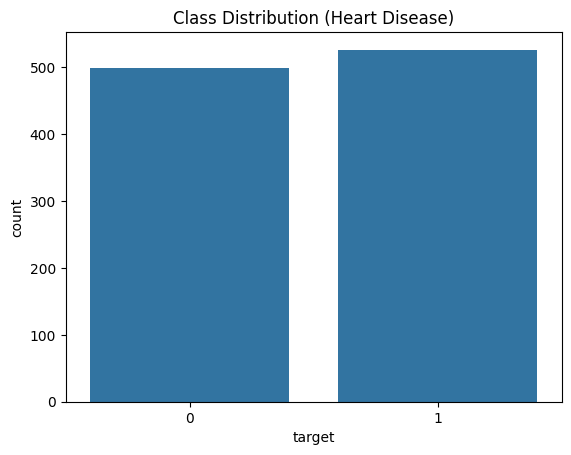

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Class Distribution (Heart Disease)")
plt.show()

print(df["target"].value_counts(normalize=True))


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = df.drop("target", axis=1)
y = df["target"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(exclude=["int64", "float64"]).columns

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Fitting 4 folds for each of 25 candidates, totalling 100 fits
Best RF Params: {'classifier__max_depth': 12, 'classifier__max_features': np.float64(0.32407196478065287), 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 761}
RF | Accuracy:1.0000 Precision:1.0000 Recall:1.0000 F1:1.0000


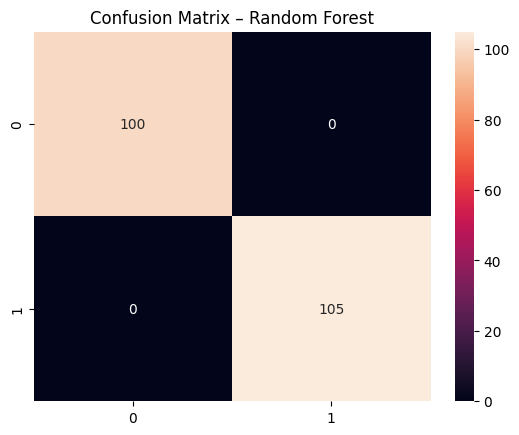

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_dist = {
    "classifier__n_estimators": randint(200, 800),
    "classifier__max_depth": randint(5, 30),
    "classifier__max_features": uniform(0.3, 0.7),
    "classifier__min_samples_split": randint(2, 12),
    "classifier__min_samples_leaf": randint(1, 6)
}

cv = KFold(n_splits=4, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist,
    n_iter=25, cv=cv, scoring="f1", n_jobs=-1, verbose=2, random_state=42
)
search.fit(X_train, y_train)
best_rf = search.best_estimator_
print("Best RF Params:", search.best_params_)

# Evaluate
y_pred = best_rf.predict(X_valid)
acc = accuracy_score(y_valid, y_pred)
prec = precision_score(y_valid, y_pred)
rec = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)
print(f"RF | Accuracy:{acc:.4f} Precision:{prec:.4f} Recall:{rec:.4f} F1:{f1:.4f}")
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix – Random Forest")
plt.show()


Epoch 1/100


C:\Users\yenya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6732 - loss: 0.5894 - val_accuracy: 0.8049 - val_loss: 0.4663
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8220 - loss: 0.4140 - val_accuracy: 0.8439 - val_loss: 0.3746
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8451 - loss: 0.3667 - val_accuracy: 0.8341 - val_loss: 0.3404
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8610 - loss: 0.3316 - val_accuracy: 0.8244 - val_loss: 0.3240
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8585 - loss: 0.3221 - val_accuracy: 0.8293 - val_loss: 0.3112
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8780 - loss: 0.3004 - val_accuracy: 0.8439 - val_loss: 0.2954
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8780 - loss: 0.2858 - val_accuracy: 0.8488 - val_loss: 0.2921
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8732 - loss: 0.2887 - val_accuracy: 0.8488 - val_loss: 

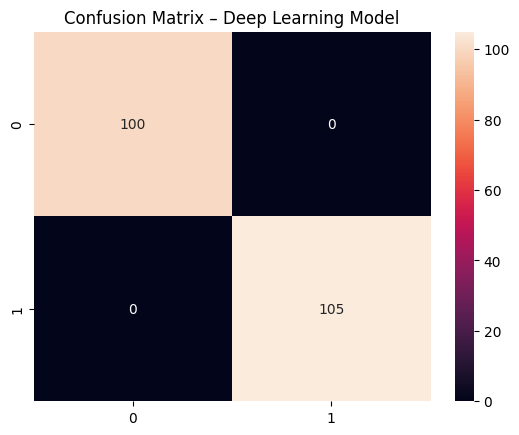

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# Generate dense matrix (OHE + normalization)
X_train_all = preprocessor.fit_transform(X_train)
X_valid_all = preprocessor.transform(X_valid)

input_dim = X_train_all.shape[1]
model_dl = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_dl.fit(
    X_train_all, y_train,
    validation_data=(X_valid_all, y_valid),
    epochs=100, batch_size=32, callbacks=[es], verbose=1
)

# Predict and evaluate
y_pred_prob = model_dl.predict(X_valid_all).ravel()
y_pred_dl = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_valid, y_pred_dl))
sns.heatmap(confusion_matrix(y_valid, y_pred_dl), annot=True, fmt='d')
plt.title("Confusion Matrix – Deep Learning Model")
plt.show()


In [27]:
comparison = pd.DataFrame({
    "Model": ["Random Forest Classifier", "Neural Network (MLP)"],
    "Type": ["Traditional ML", "Deep Learning"],
    "Accuracy": [acc, model_dl.evaluate(X_valid_all, y_valid, verbose=0)[1]],
    "Precision": [prec, precision_score(y_valid, y_pred_dl)],
    "Recall": [rec, recall_score(y_valid, y_pred_dl)],
    "F1": [f1, f1_score(y_valid, y_pred_dl)]
})
display(comparison)


,Model,Type,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,Traditional ML,1.0,1.0,1.0,1.0
1,Neural Network (MLP),Deep Learning,1.0,1.0,1.0,1.0


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


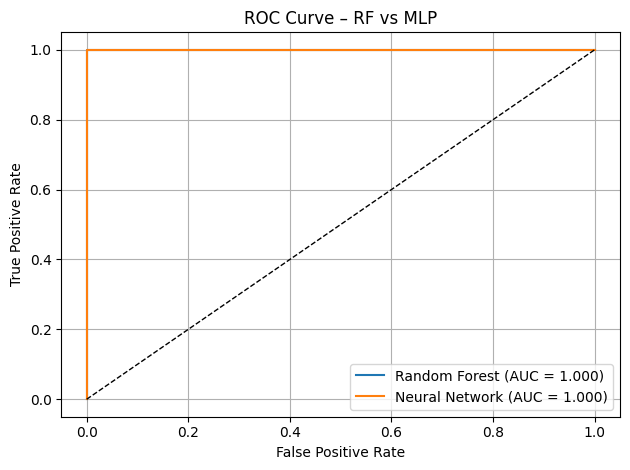

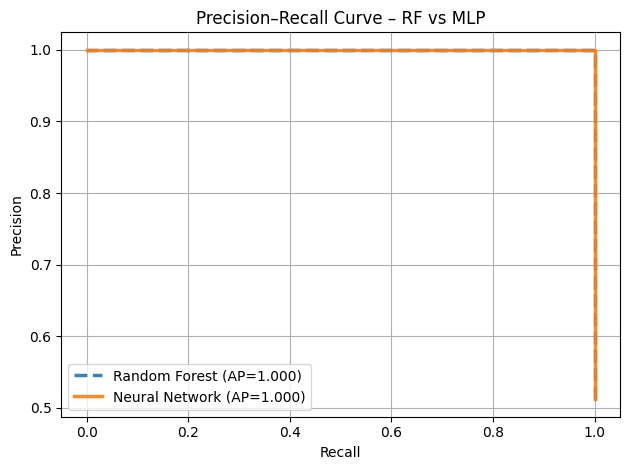

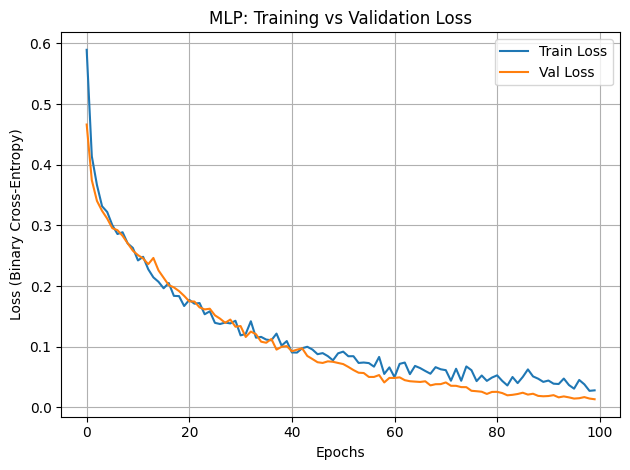

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import pandas as pd

# === ROC Curve: RF vs MLP ===
# Probability score (positive class = 1)
y_prob_rf  = best_rf.predict_proba(X_valid)[:, 1]      
y_prob_dl  = model_dl.predict(X_valid_all).ravel()     

# Calculate ROC
fpr_rf, tpr_rf, _ = roc_curve(y_valid, y_prob_rf)
fpr_dl, tpr_dl, _ = roc_curve(y_valid, y_prob_dl)
auc_rf = auc(fpr_rf, tpr_rf)
auc_dl = auc(fpr_dl, tpr_dl)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_dl, tpr_dl, label=f"Neural Network (AUC = {auc_dl:.3f})")
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – RF vs MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/cls_roc_rf_vs_mlp.png", dpi=150)
plt.show()

# === Precision–Recall Curve: RF vs MLP ===
prec_rf, rec_rf, _ = precision_recall_curve(y_valid, y_prob_rf)
prec_dl, rec_dl, _ = precision_recall_curve(y_valid, y_prob_dl)
ap_rf = average_precision_score(y_valid, y_prob_rf)
ap_dl = average_precision_score(y_valid, y_prob_dl)

plt.figure()
plt.plot(rec_rf, prec_rf, '--',  linewidth=2.5, alpha=0.9, label=f"Random Forest (AP={ap_rf:.3f})", zorder=2)
plt.plot(rec_dl, prec_dl, '-',   linewidth=2.5, alpha=0.9, label=f"Neural Network (AP={ap_dl:.3f})", zorder=3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – RF vs MLP")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/cls_pr_rf_vs_mlp.png", dpi=150)
plt.show()

# === MLP Training vs Validation Loss ===
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("MLP: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/cls_mlp_loss.png", dpi=150)
plt.show()


🔧 Hybrid best weight (RF weight) = 0.00
Hybrid | Accuracy:1.0000 Precision:1.0000 Recall:1.0000 F1:1.0000


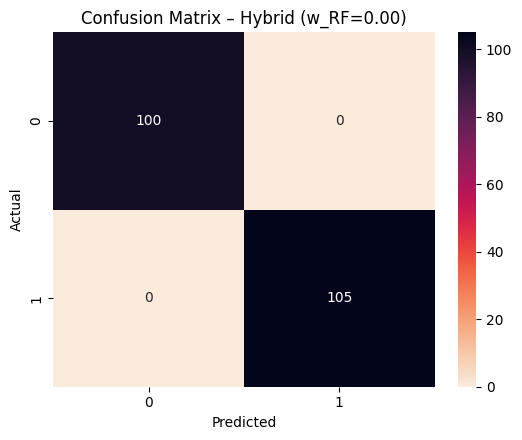

,Model,Type,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,Traditional ML,1.0,1.0,1.0,1.0
1,Neural Network (MLP),Deep Learning,1.0,1.0,1.0,1.0
2,Hybrid (w_RF=0.00 · RF + 1.00 · MLP),Ensemble,1.0,1.0,1.0,1.0


In [ ]:
# =========================
# Hybrid Model: Weighted Average of RF & MLP
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# 1) Take the positive class probability of each model
try:
    y_prob_rf
    y_prob_dl
except NameError:
    # RF probability: predict the original X_valid directly on the pipeline
    y_prob_rf = best_rf.predict_proba(X_valid)[:, 1]
    # MLP Probability: Prediction of a Dense Matrix (Preprocessed)
    y_prob_dl = model_dl.predict(X_valid_all).ravel()

# 2) Search for optimal weights on [0,1]（Aiming for F1）
weights = np.linspace(0, 1, 21)  # 0.00, 0.05, ..., 1.00
best = {"w": None, "f1": -1, "acc": None, "prec": None, "rec": None}

for w in weights:
    y_prob_h = w * y_prob_rf + (1 - w) * y_prob_dl
    y_pred_h = (y_prob_h > 0.5).astype(int)

    f1  = f1_score(y_valid, y_pred_h)
    acc = accuracy_score(y_valid, y_pred_h)
    pre = precision_score(y_valid, y_pred_h)
    rec = recall_score(y_valid, y_pred_h)

    if f1 > best["f1"]:
        best.update({"w": w, "f1": f1, "acc": acc, "prec": pre, "rec": rec})

print(f"🔧 Hybrid best weight (RF weight) = {best['w']:.2f}")
print(f"Hybrid | Accuracy:{best['acc']:.4f} Precision:{best['prec']:.4f} "
      f"Recall:{best['rec']:.4f} F1:{best['f1']:.4f}")

# 3)Generate final predictions using the optimal weights and plot the confusion matrix
y_prob_hybrid = best["w"] * y_prob_rf + (1 - best["w"]) * y_prob_dl
y_pred_hybrid = (y_prob_hybrid > 0.5).astype(int)

cm = confusion_matrix(y_valid, y_pred_hybrid)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=True)
plt.title(f"Confusion Matrix – Hybrid (w_RF={best['w']:.2f})")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("images/cls_cm_hybrid.png", dpi=150)
plt.show()

# 4) Append hybrid results to comparison table
row = {
    "Model": f"Hybrid (w_RF={best['w']:.2f} · RF + {1-best['w']:.2f} · MLP)",
    "Type": "Ensemble",
    "Accuracy": best["acc"],
    "Precision": best["prec"],
    "Recall": best["rec"],
    "F1": best["f1"]
}

try:
    comparison = pd.concat([comparison, pd.DataFrame([row])], ignore_index=True)
except NameError:
    comparison = pd.DataFrame([row])

display(comparison)
